# Regression
---
## Marketing tool
L’obiettivo di questo notebook è sviluppare un modello che, analizzando i rating sia in grado di predirre il prezzo del telefono.
Questo sistema può essere utilizzato come strumento di marketing per personalizzare le offerte, migliorare l’esperienza utente e supportare decisioni strategiche basate sui dati.

### Import dataset


In [12]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("./data/Mobile Reviews Sentiment.csv")

### Pulizia dataset

In [13]:
features = ["battery_life_rating", "camera_rating", "performance_rating", "design_rating", "display_rating"]
colonne_da_tenere = features + ["price_usd"]
df_clean = df[colonne_da_tenere].copy()

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   battery_life_rating  50000 non-null  int64  
 1   camera_rating        50000 non-null  int64  
 2   performance_rating   50000 non-null  int64  
 3   design_rating        50000 non-null  int64  
 4   display_rating       50000 non-null  int64  
 5   price_usd            50000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 2.3 MB


### Scaling

In [14]:
X = df_clean[features]
y = df_clean['price_usd']

X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(40000, 5) (10000, 5)
(40000,) (10000,)


### Rete neurale

In [15]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(15, activation="relu"),
    keras.layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

C:\Users\julic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 30)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 661 (2.58 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 0 (0.00 B)

### Addrestramento

In [16]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-5
    )
]
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), callbacks=callbacks)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step - loss: 264574.3750 - mae: 412.6340 - val_loss: 121099.7500 - val_mae: 276.8058 - learning_rate: 0.0010
Epoch 2/20
 291/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - loss: 117339.2670 - mae: 274.0949

C:\Users\julic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: loss,mae,val_loss,val_mae
  current = self.get_monitor_value(logs)
C:\Users\julic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_auc` which is not available. Available metrics are: loss,mae,val_loss,val_mae,learning_rate.
  callback.on_epoch_end(epoch, logs)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step - loss: 102901.6016 - mae: 260.4502 - val_loss: 97138.3359 - val_mae: 256.8767 - learning_rate: 0.0010
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step - loss: 96654.6641 - mae: 255.1463 - val_loss: 96546.7891 - val_mae: 255.4435 - learning_rate: 0.0010
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step - loss: 96424.8828 - mae: 254.9197 - val_loss: 96472.2578 - val_mae: 255.5125 - learning_rate: 0.0010
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 665us/step - loss: 96405.1328 - mae: 254.8333 - val_loss: 96493.1875 - val_mae: 256.1155 - learning_rate: 0.0010
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 665us/step - loss: 96354.0703 - mae: 254.9000 - val_loss: 96470.7266 - val_mae: 255.0352 - learning_rate: 0.0010
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step - loss: 96382.9219 - mae: 254.8088 - val_loss: 96653.4766 - val_mae: 256.7601 - learning_rate: 0.0010
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step - loss

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step


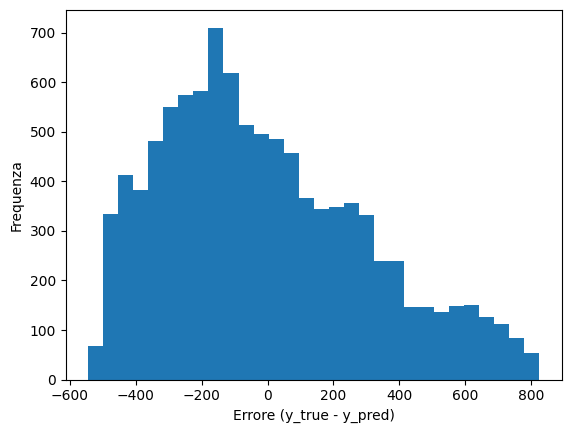

In [19]:
import matplotlib.pyplot as plt
y_pred = model.predict(X_test)

errori = y_test - y_pred.squeeze()

plt.hist(errori, bins=30)
plt.xlabel("Errore (y_true - y_pred)")
plt.ylabel("Frequenza")
plt.show()


### Valutazione del modello
Dal grafico degli errori possiamo notare che il modello tende a sovrastimare le proprie predizioni: la maggior parte degli errori è negativa, con valori che si concentrano intorno a −200 USD, indicando che il modello predice spesso prezzi più alti rispetto al valore reale.
Questo comportamento può essere dovuto al dataset: ad esempio, molte recensioni descrivono telefoni come prodotti di alta qualità, inducendo il modello a sovrastimare il prezzo reale, che in pratica risulta più basso.
Si osserva inoltre una coda verso destra, che indica la presenza di outlier, con errori che arrivano fino a +800 USD. Questi casi rappresentano forti sottostime, ma sono poco frequenti. La maggior parte degli errori positivi, infatti, si concentra tra 200 e 400 USD.